# CRNN OCR Model Testing in Google Colab


In [1]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# ১. জিপিইউ মেমোরি গ্রোথ সেটআপ
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Could not set memory growth:", e)



In [2]:
# 2. Mount the google Drive :

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 3. Path and Constand Designing part :
SAVE_DIR = "/content/drive/MyDrive/handwriting_sentence_ocr"
os.makedirs(SAVE_DIR, exist_ok=True)

IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
CSV_LABEL_CANDIDATES = ["label", "text", "transcription", "sentence", "gt", "ground_truth"]
CSV_PATH_CANDIDATES = ["image_path", "image", "path", "filename", "file", "img_path", "file_name"]



In [4]:
# 4. Image and Label processing function (Dataset Loader)
def index_images(root):
    by_stem = {}
    all_paths = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTS):
                full = os.path.join(dirpath, fname)
                stem = os.path.splitext(fname)[0]
                by_stem[stem] = full
                all_paths.append(full)
    return by_stem, all_paths

def parse_csv_annotation(path):
    sep = "\t" if path.lower().endswith(".tsv") else ","
    df = pd.read_csv(path, sep=sep)
    df.columns = [str(c).strip().lower() for c in df.columns]

    label_col = next((c for c in CSV_LABEL_CANDIDATES if c in df.columns), None)
    path_col = next((c for c in CSV_PATH_CANDIDATES if c in df.columns), None)
    if label_col is None or path_col is None:
        return None
    return list(zip(df[path_col].astype(str), df[label_col].astype(str)))

def build_dataframe(root):
    by_stem, all_paths = index_images(root)
    if not all_paths:
        raise RuntimeError(f"No image files found under {root}")

    # এখানে ধরে নেওয়া হচ্ছে কািগল ডেটাসেট থেকে ফাইলগুলো পাওয়া গেছে
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith((".csv", ".tsv")):
                ann_path = os.path.join(dirpath, fname)
                rows = parse_csv_annotation(ann_path)
                if rows:
                    records = []
                    for id_or_path, label in rows:
                        candidate_path = id_or_path if os.path.isabs(id_or_path) else os.path.join(root, id_or_path)
                        if os.path.isfile(candidate_path):
                            resolved = candidate_path
                        else:
                            stem = os.path.splitext(os.path.basename(id_or_path))[0]
                            resolved = by_stem.get(stem)
                        if resolved:
                            records.append((resolved, label))
                    if records:
                        df = pd.DataFrame(records, columns=["image", "label"])
                        return df.drop_duplicates(subset=["image"]).reset_index(drop=True)
    raise RuntimeError("No valid annotation file found.")

# ৫. ভোকেabulary লোড বা সেভ করার ফাংশন
def load_saved_vocab(save_dir):
    vocab_path = os.path.join(save_dir, "vocab.json")
    if os.path.exists(vocab_path):
        with open(vocab_path, "r", encoding="utf-8") as f:
            v = json.load(f)
        v["num_to_char"] = {int(k): c for k, c in v["num_to_char"].items()}
        return v
    return None

# ৬. CTC লস ফাংশন
def ctc_loss_fn(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    batch_len = tf.shape(y_true)[0]
    input_length = tf.shape(y_pred)[1]
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int32")
    label_length = tf.math.count_nonzero(y_true != 65, axis=-1, keepdims=True)
    label_length = tf.cast(label_length, tf.int32)
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)



In [5]:
# ৭. প্রেডিকশন ফাংশন
def predict_sentence(image_path, model, v):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img.set_shape([None, None, 1])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, v["image_height"], v["image_width"])
    img = tf.transpose(img, perm=[1, 0, 2])  # (H, W, C) -> (W, H, C)
    img = tf.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    decoded = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0].numpy()

    num_to_char_local = v["num_to_char"]
    return "".join(num_to_char_local[idx] for idx in decoded[0] if idx in num_to_char_local)





মডেল এবং ভোকেabulary সফলভাবে লোড হয়েছে!


Saving WhatsApp Image 2026-08-01 at 10.17.10 AM (2).jpeg to WhatsApp Image 2026-08-01 at 10.17.10 AM (2) (1).jpeg
Predicted sentence: Crositoon


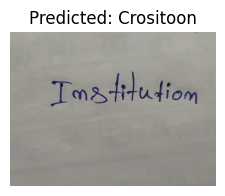

In [20]:
# ৮. মডেল এবং ভোকেabulary টেস্ট রান (যদি ফাইল সেভ করা থাকে)
from google.colab import files

v = load_saved_vocab(SAVE_DIR)
model_path = os.path.join(SAVE_DIR, "model.keras")

if v and os.path.exists(model_path):
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={"ctc_loss_fn": ctc_loss_fn},
        compile=False,
    )
    print("মডেল এবং ভোকেabulary সফলভাবে লোড হয়েছে!")

    # টেস্ট ইমেজ পাথ
    uploaded = files.upload()
    IMAGE_TO_PREDICT = list(uploaded.keys())[0]
    if os.path.exists(IMAGE_TO_PREDICT):
        predicted_text = predict_sentence(IMAGE_TO_PREDICT, model, v)
        print("Predicted sentence:", predicted_text)

        plt.figure(figsize=(10, 2))
        plt.imshow(Image.open(IMAGE_TO_PREDICT), cmap="gray")
        plt.title(f"Predicted: {predicted_text}")
        plt.axis("off")
        plt.show()
    else:
        print("দয়া করে সঠিক টেস্ট ইমেজ পাথ প্রদান করুন।")
else:
    print("সেভ করা মডেল বা ভোকেabulary পাওয়া যায়নি। দয়া করে আগে মডেল ট্রেইন করে সেভ করুন।")

In [ ]:
Flexibac